In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [21]:
df = pd.read_csv(
    r"C:\Users\abera\Downloads\cleaned_telco_churn.csv"
)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
print(df.shape)

df.info()

(7021, 20)
<class 'pandas.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     7021 non-null   str    


In [23]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,7021,2,Male,3541,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7021.0,NaN,NaN,NaN,0.162512,0.368947,0.0,0.0,0.0,0.0,1.0
Partner,7021,2,No,3619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7021,2,No,4911,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7021.0,NaN,NaN,NaN,32.469449,24.534965,0.0,9.0,29.0,55.0,72.0
PhoneService,7021,2,Yes,6339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7021,3,No,3368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7021,3,Fiber optic,3090,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7021,3,No,3490,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,7021,3,No,3080,NaN,NaN,NaN,NaN,NaN,NaN,NaN


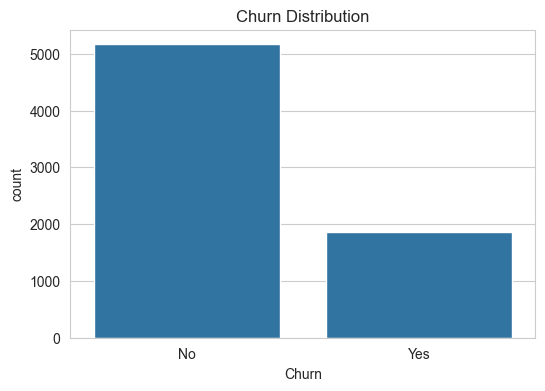

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=df
)

plt.title('Churn Distribution')

plt.show()

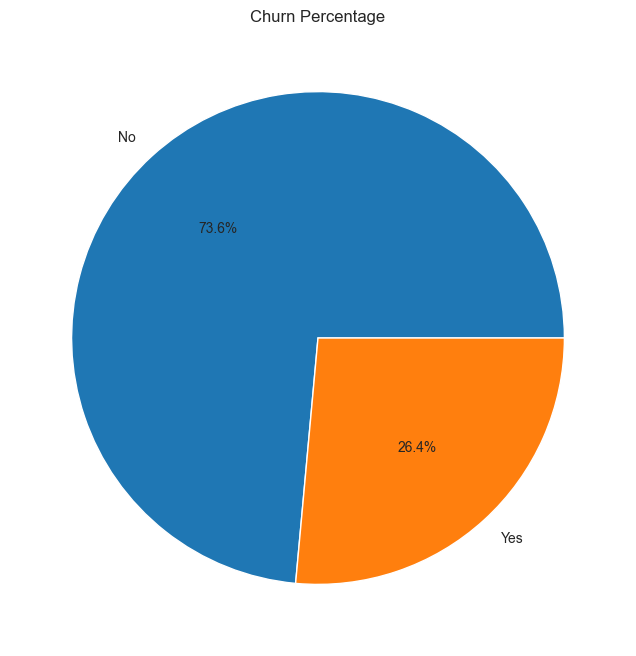

In [25]:
plt.figure(figsize=(8,8))

df['Churn'].value_counts().plot.pie(
    autopct='%1.1f%%'
)

plt.title('Churn Percentage')

plt.ylabel('')

plt.show()

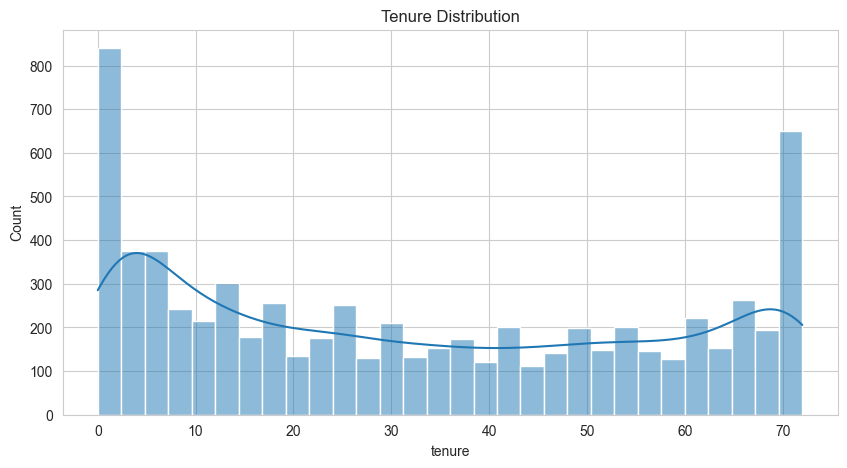

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['tenure'],
    bins=30,
    kde=True
)

plt.title('Tenure Distribution')

plt.show()

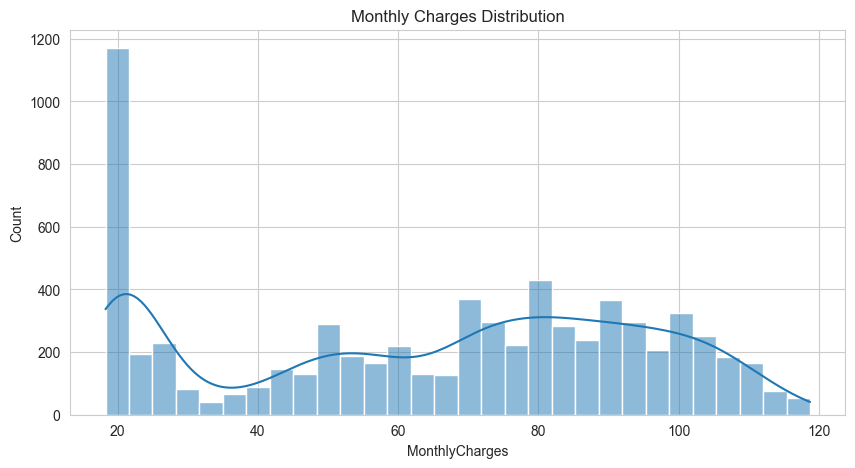

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['MonthlyCharges'],
    bins=30,
    kde=True
)

plt.title('Monthly Charges Distribution')

plt.show()

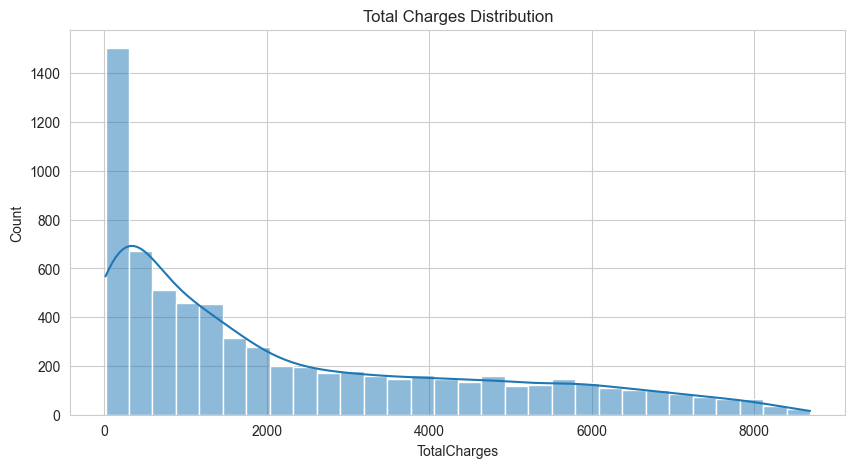

In [28]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['TotalCharges'],
    bins=30,
    kde=True
)

plt.title('Total Charges Distribution')

plt.show()

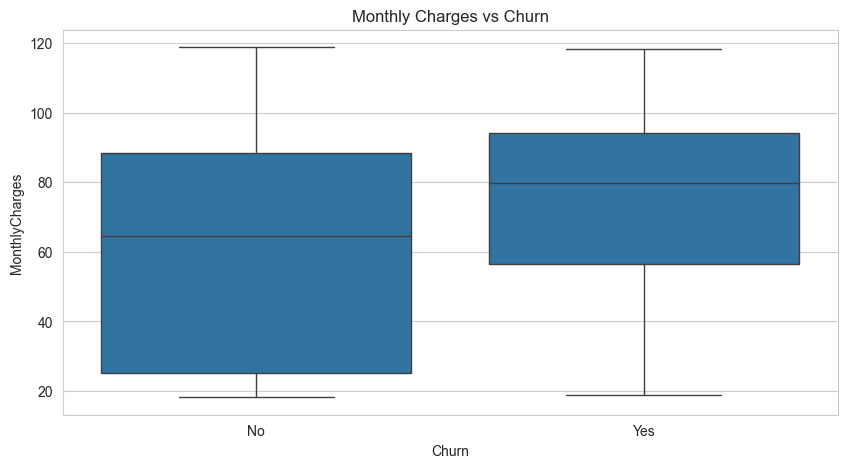

In [29]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title('Monthly Charges vs Churn')

plt.show()

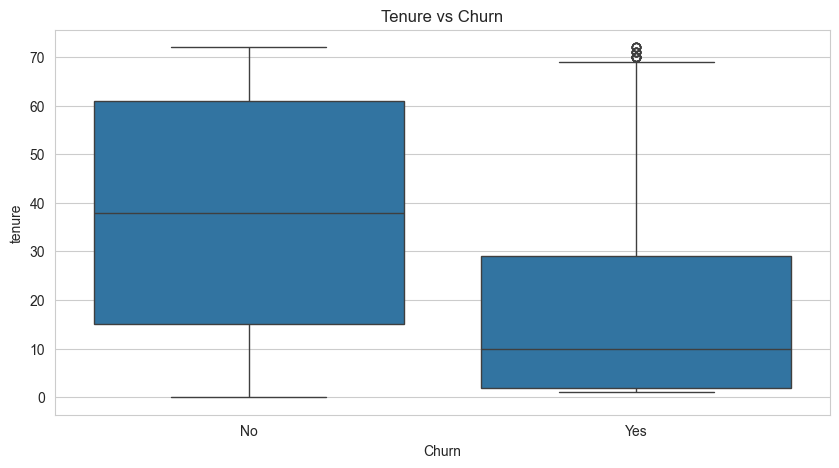

In [30]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.title('Tenure vs Churn')

plt.show()

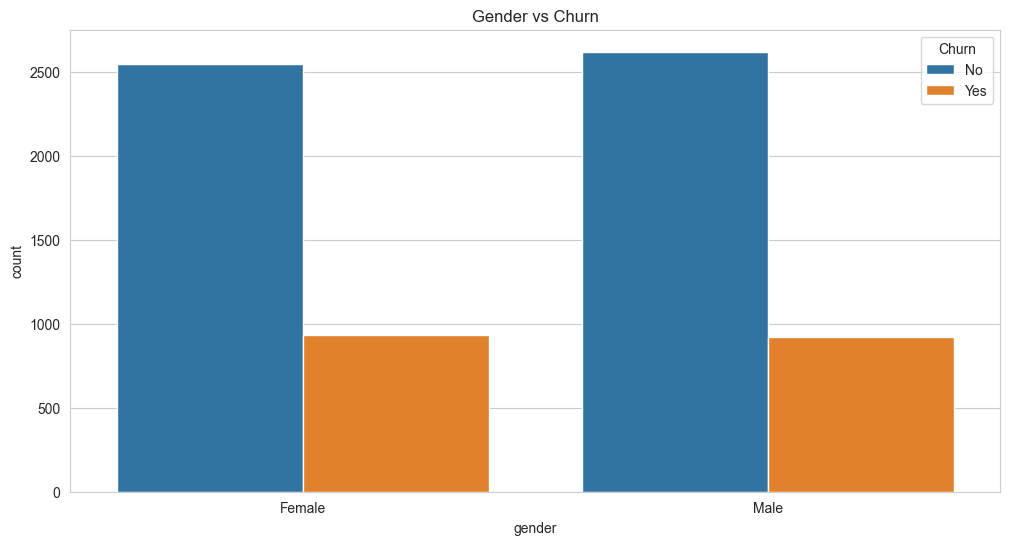

In [31]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='gender',
    hue='Churn',
    data=df
)

plt.title('Gender vs Churn')

plt.show()

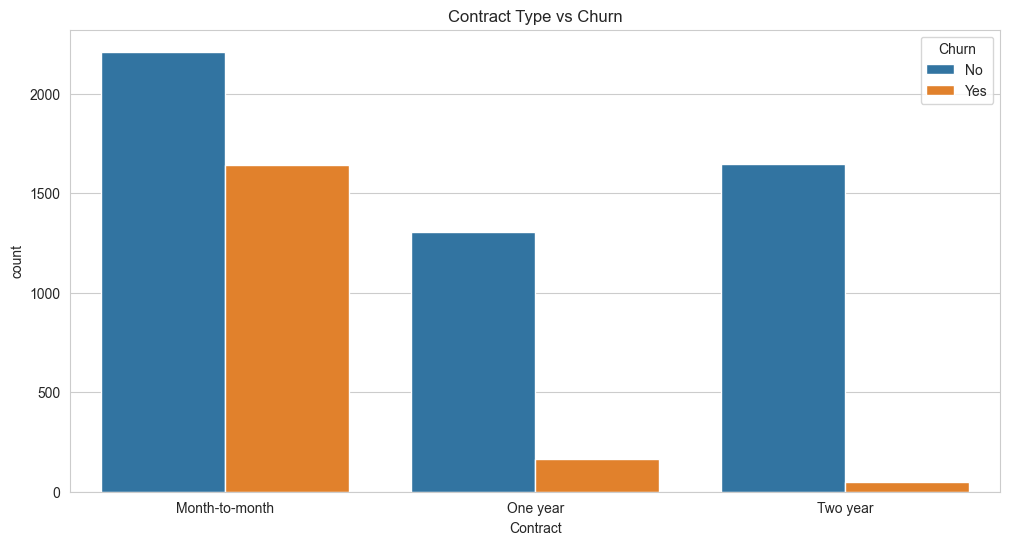

In [32]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title('Contract Type vs Churn')

plt.show()

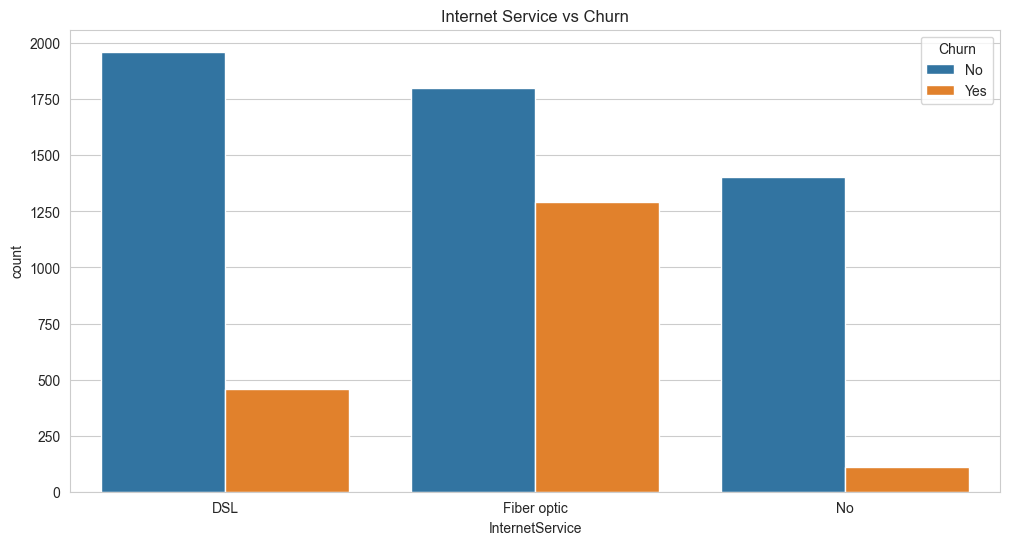

In [33]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.title('Internet Service vs Churn')

plt.show()

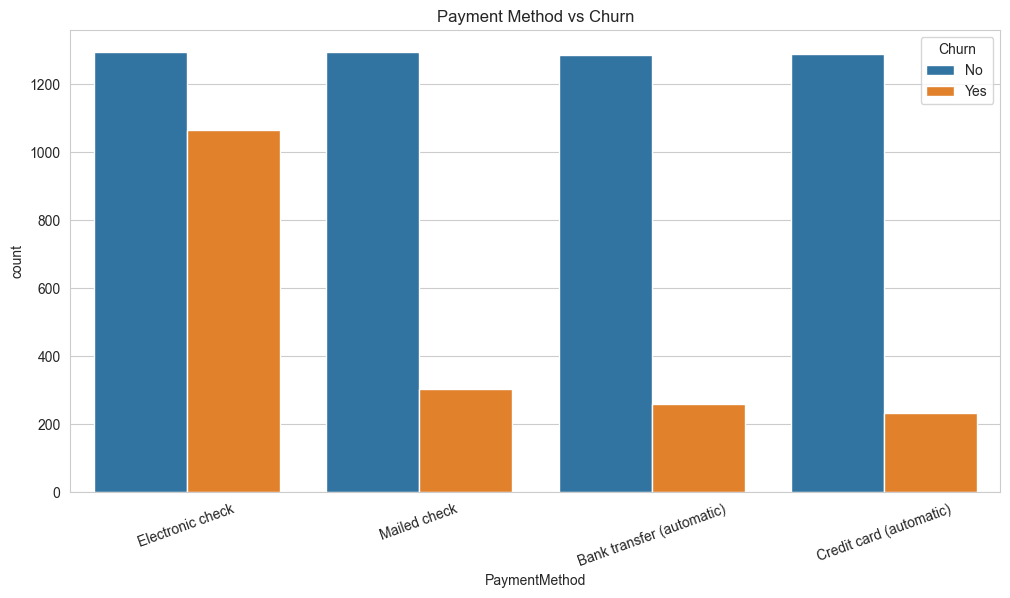

In [34]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)

plt.xticks(rotation=20)

plt.title('Payment Method vs Churn')

plt.show()

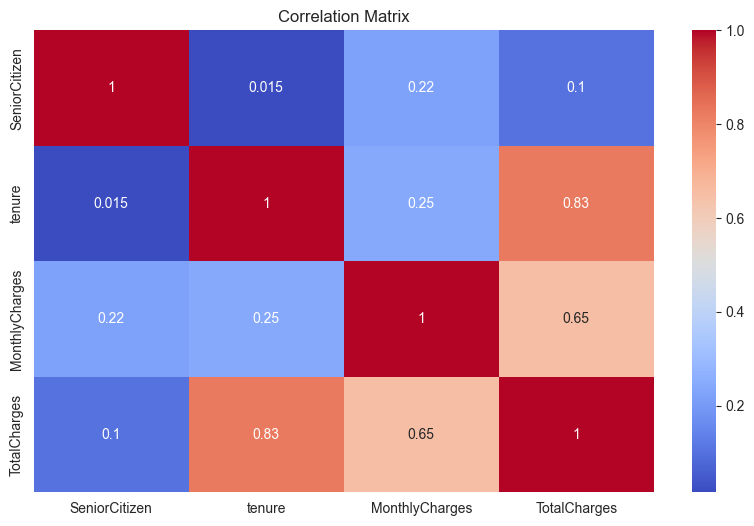

In [35]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

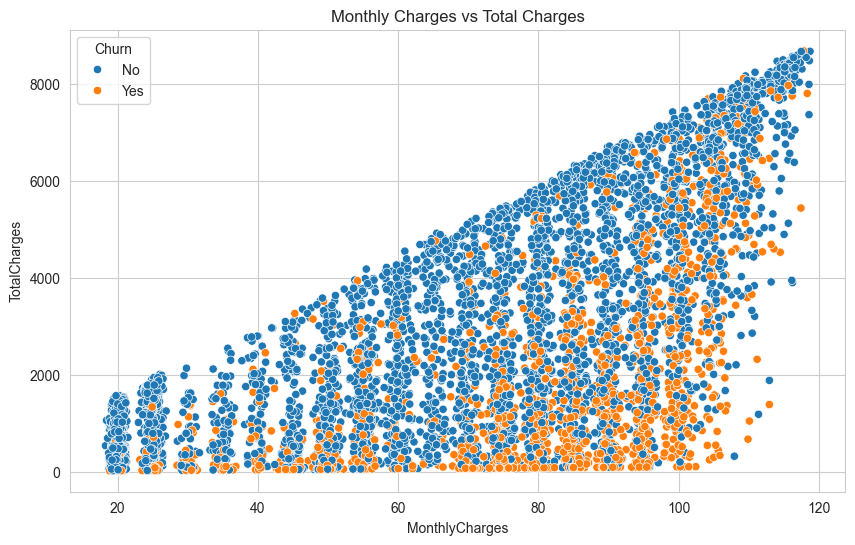

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='MonthlyCharges',
    y='TotalCharges',
    hue='Churn',
    data=df
)

plt.title('Monthly Charges vs Total Charges')

plt.show()

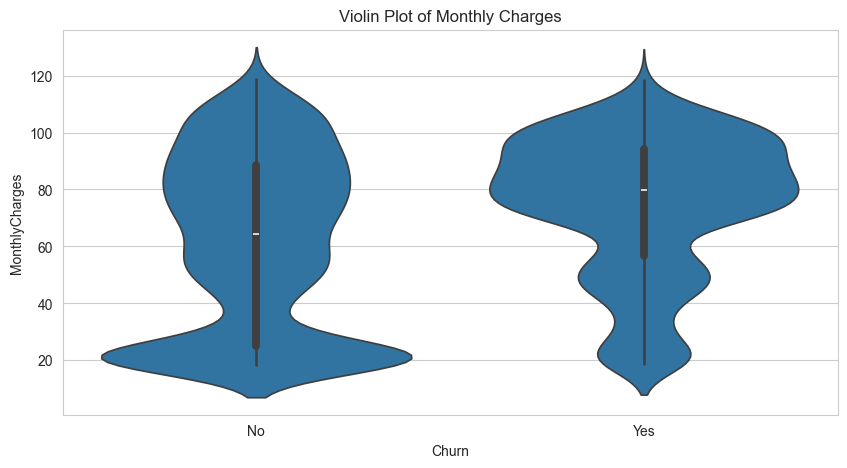

In [37]:
plt.figure(figsize=(10,5))

sns.violinplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title('Violin Plot of Monthly Charges')

plt.show()

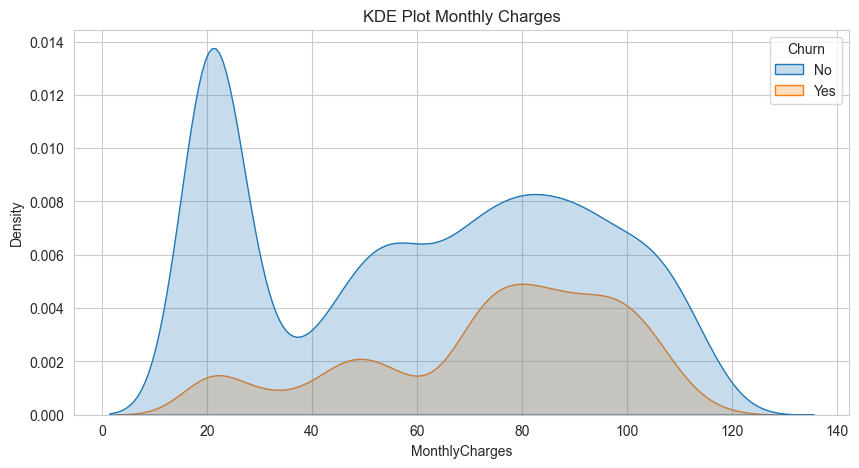

In [38]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    data=df,
    x='MonthlyCharges',
    hue='Churn',
    fill=True
)

plt.title('KDE Plot Monthly Charges')

plt.show()

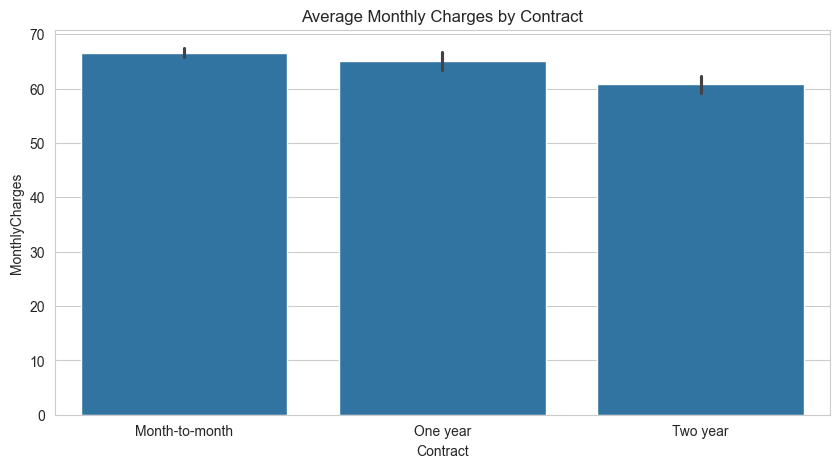

In [39]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Contract',
    y='MonthlyCharges',
    data=df
)

plt.title('Average Monthly Charges by Contract')

plt.show()